# AMC a bajo SNR — Opción 1a: Momentos/Cumulantes de orden superior (HOS)

Entrena `HOSClassifier` (`../common_snr/models.py`) sobre momentos y cumulantes de orden
superior (`compute_hos_features` en `../common_snr/features.py`) en vez de I/Q crudo. La
robustez a bajo SNR se espera de la *feature*: los cumulantes de orden ≥4 de un ruido gaussiano
son ~0 (validado numéricamente al construir `features.py`), así que en teoría siguen reflejando
la estructura de la modulación incluso cuando el ruido domina la señal.

Ver `../README.md` para el resto de las estrategias evaluadas y por qué.


## 1. Imports y configuración

In [6]:
import sys
sys.path.insert(0, "../../Modelos iniciales")  # common/: data.py, train.py (no se duplican acá)
sys.path.insert(0, "..")                       # common_snr/: features.py, models.py de esta carpeta

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common_snr.models import HOSClassifier
from common_snr.features import compute_hos_features
from common.data import load_radioml_digital, split_dataset, make_loader
from common.train import train_model, evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 256
EPOCHS = 50
PATIENCE = 10
SEED = 42

# Hiperparámetros de arquitectura — modificar acá para probar otra profundidad/ancho.
# n_features es fijo (16): es la cantidad de momentos/cumulantes que devuelve
# compute_hos_features, no depende del dataset — por eso va como literal y no como
# X_train.shape[1] (X_train recién se crea en la próxima celda).
MODEL_KWARGS = dict(n_features=16, hidden=(32, 16), dropout=0.3)

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga, split y transformación de features

In [7]:
X, y, snrs, le = load_radioml_digital(dataset_folder="../../Modelos iniciales/rfml", seed=SEED)
N_CLASSES = len(le.classes_)
print(f"Clases ({N_CLASSES}): {list(le.classes_)}")

(X_train, y_train, snr_train), (X_val, y_val, snr_val), (X_test, y_test, snr_test) = split_dataset(
    X, y, snrs, seed=SEED
)

# HOS se calcula sobre I/Q crudo — no hace falta aumentar los datos, solo resumir cada señal
# en su vector de momentos/cumulantes (ver compute_hos_features). Igual que con to_amplitude_phase
# en Modelos iniciales, se transforma recién después del split para no filtrar información entre
# splits ni duplicar código de carga.
X_train = compute_hos_features(X_train)
X_val = compute_hos_features(X_val)
X_test = compute_hos_features(X_test)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

Clases (8): ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK']
Train: (96000, 16) | Val: (32000, 16) | Test: (32000, 16)


## 3. Entrenamiento — HOS

In [8]:
print("=== HOS ===")
print(f"Configuración: {MODEL_KWARGS}")
model = HOSClassifier(n_classes=N_CLASSES, **MODEL_KWARGS)
print(f"Parámetros: {model.count_parameters():,}")

model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, device=DEVICE
)
history["model_kwargs"] = MODEL_KWARGS

torch.save(model.state_dict(), "hos.pt")
with open("history.pkl", "wb") as f:
    pickle.dump(history, f)

=== HOS ===
Configuración: {'n_features': 16, 'hidden': (32, 16), 'dropout': 0.3}
Parámetros: 1,304
Época  10/50 | Train Loss: 1.4755 | Val Loss: 1.4303 | Val Acc: 0.4282 | Patience: 4/10
Época  20/50 | Train Loss: 1.4488 | Val Loss: 1.4413 | Val Acc: 0.4312 | Patience: 7/10
Época  30/50 | Train Loss: 1.4402 | Val Loss: 1.5109 | Val Acc: 0.4256 | Patience: 7/10
Época  33/50 | Train Loss: 1.4338 | Val Loss: 1.4504 | Val Acc: 0.4379 | Patience: 10/10
Early stopping en época 33. Mejor val_loss: 1.3526


## 4. Evaluación (foco en bajo SNR)

In [9]:
acc = overall_accuracy(model, X_test, y_test, device=DEVICE)
snr_acc = evaluate_by_snr(model, X_test, y_test, snr_test, device=DEVICE)

print(f"Accuracy global — HOS: {acc:.4f}")
print(f"Parámetros: {model.count_parameters():,}")

# El límite físico de información de Fisher para AMC está, en la práctica, entre -10 y -14 dB
# (ver ../README.md) — reportamos aparte la accuracy por debajo y por encima de ese umbral.
mask_muy_bajo = snr_test <= -10
mask_resto = snr_test > -10
acc_muy_bajo = overall_accuracy(model, X_test[mask_muy_bajo], y_test[mask_muy_bajo], device=DEVICE)
acc_resto = overall_accuracy(model, X_test[mask_resto], y_test[mask_resto], device=DEVICE)
print(f"Accuracy SNR <= -10 dB: {acc_muy_bajo:.4f} (n={mask_muy_bajo.sum()})")
print(f"Accuracy SNR >  -10 dB: {acc_resto:.4f} (n={mask_resto.sum()})")

Accuracy global — HOS: 0.4420
Parámetros: 1,304
Accuracy SNR <= -10 dB: 0.1283 (n=9641)
Accuracy SNR >  -10 dB: 0.5773 (n=22359)


## 5. Gráficos

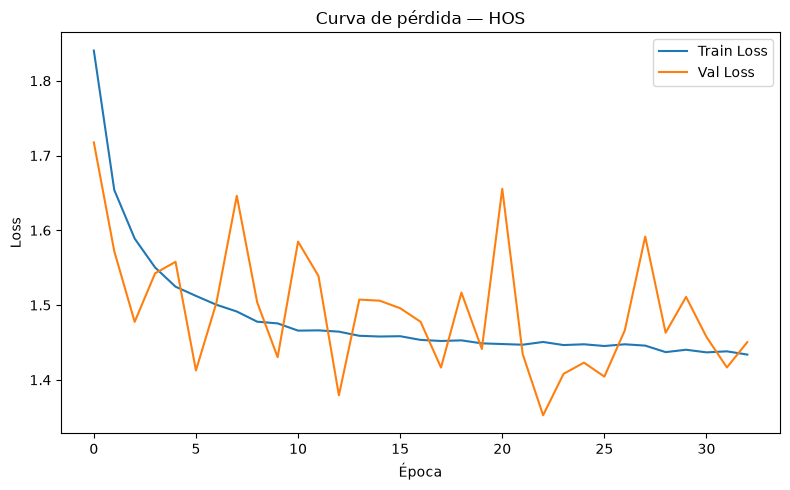

In [10]:
# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida — HOS")
plt.legend()
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150)
plt.show()

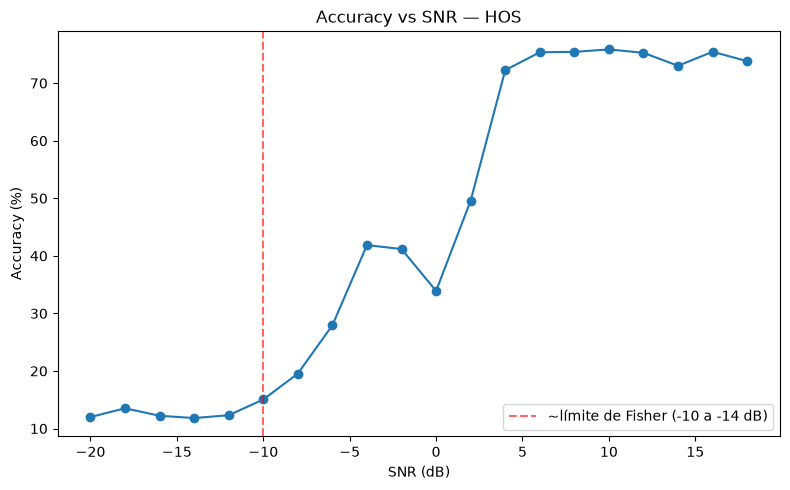

In [11]:
# Accuracy vs SNR — con línea de referencia en -10 dB (límite físico aproximado, ver README)
snr_levels = sorted(snr_acc.keys())
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o")
plt.axvline(-10, color="red", linestyle="--", alpha=0.6, label="~límite de Fisher (-10 a -14 dB)")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — HOS")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

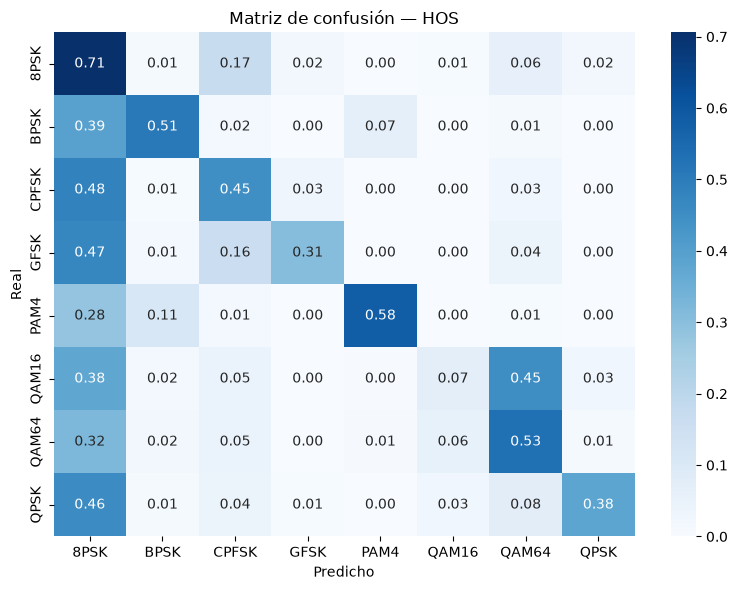

In [12]:
# Matriz de confusión (todos los SNR)
cm = compute_cm(model, X_test, y_test, device=DEVICE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — HOS")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

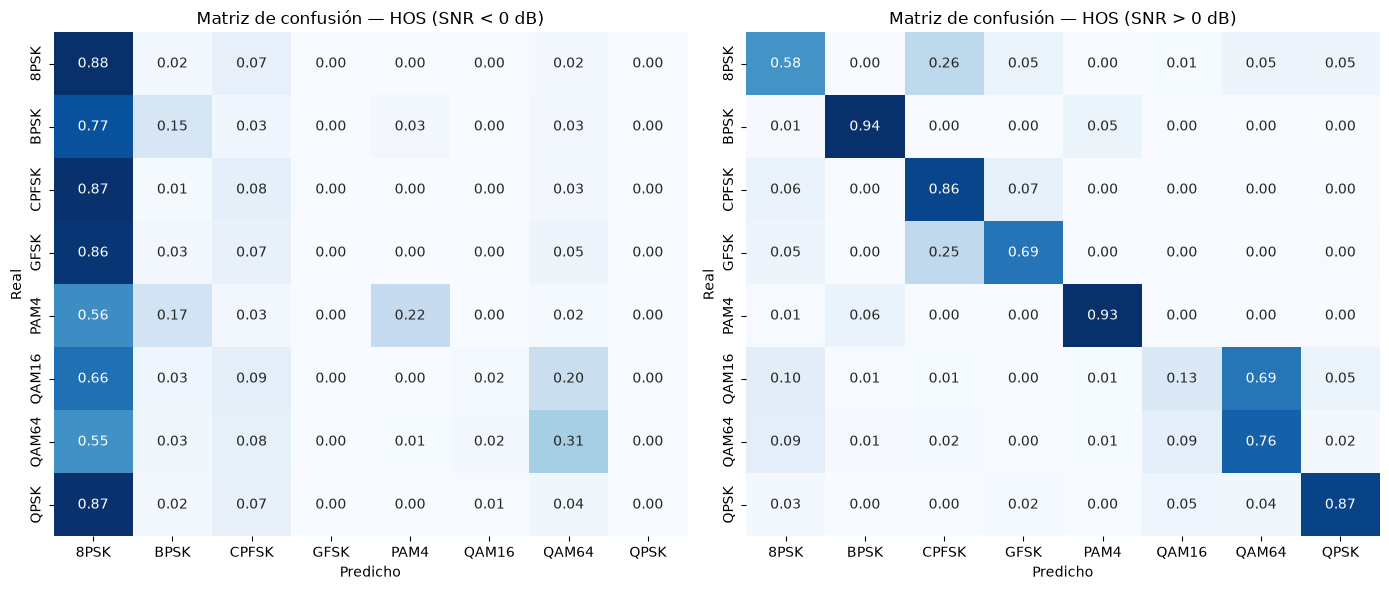

In [13]:
# Matrices de confusión por rango de SNR (bajo: <0 dB, alto: >0 dB)
mask_low = snr_test < 0
mask_high = snr_test > 0

cm_low = compute_cm(model, X_test[mask_low], y_test[mask_low], device=DEVICE)
cm_high = compute_cm(model, X_test[mask_high], y_test[mask_high], device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm_snr, titulo_snr in zip(axes, [cm_low, cm_high], ["SNR < 0 dB", "SNR > 0 dB"]):
    sns.heatmap(cm_snr, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — HOS ({titulo_snr})")
plt.tight_layout()
plt.savefig("confusion_matrix_por_snr.png", dpi=150)
plt.show()